In [5]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import pandas as pd
import os
from scipy.optimize import fsolve
import numpy as np

In [6]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 12.8


In [7]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()
        state0 = torch.zeros(
            forces.shape[1:-1] + (self.discrete_equations.nstate,), device=forces.device
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        return result[...,0:1]

In [8]:
nchunk = 50
nmodel = neml2.load_model("new_model.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_X", "E_Y", "elasticity_nu", "C_X", "g_X", "athermal_L", "athermal_b", "flow_rate_b", "rho_m_rate_L", "shear_athermal_m", "shear_eff_m",
                                                                            "sy_X", "v_disl_Bk", "v_disl_L", "v_disl_a", "v_disl_b", "v_disl_h", "v_disl_pierls_stress"]), nchunk=nchunk)

Name:       implicit_rate
Input:      G [Scalar]
            forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/gamma [Scalar]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/gamma [Scalar]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/gamma [Scalar]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: C_X [Scalar][Double][cuda:0]
            C_Y [Scalar][Double][cuda:0]
            E_X [

## Ignore the block below
The tungsten data is bad and corrupted.

--- Sample Information ---
C104: 250C, strain rate = 6.40e-04, n_points = 414
C101: 250C, strain rate = 6.40e-04, n_points = 560
C107: 250C, strain rate = 6.40e-04, n_points = 340
C115: 250C, strain rate = 6.40e-03, n_points = 96
C116: 250C, strain rate = 6.40e-03, n_points = 182
C108: 400C, strain rate = 6.40e-04, n_points = 881
C105: 400C, strain rate = 6.40e-04, n_points = 483
C102: 400C, strain rate = 6.40e-04, n_points = 404
C117: 400C, strain rate = 6.40e-03, n_points = 231
C114: 400C, strain rate = 6.40e-03, n_points = 158
C123: 400C, strain rate = 6.40e-03, n_points = 271
C118: 400C, strain rate = 6.40e-02, n_points = 377
C113: 400C, strain rate = 6.40e-02, n_points = 623
C103: 550C, strain rate = 6.40e-04, n_points = 405
C109: 550C, strain rate = 6.40e-04, n_points = 955
C106: 550C, strain rate = 6.40e-04, n_points = 384
C119: 550C, strain rate = 6.40e-03, n_points = 240
C120: 550C, strain rate = 6.40e-03, n_points = 227
C121: 550C, strain rate = 6.40e-02, n_points = 224
C122:

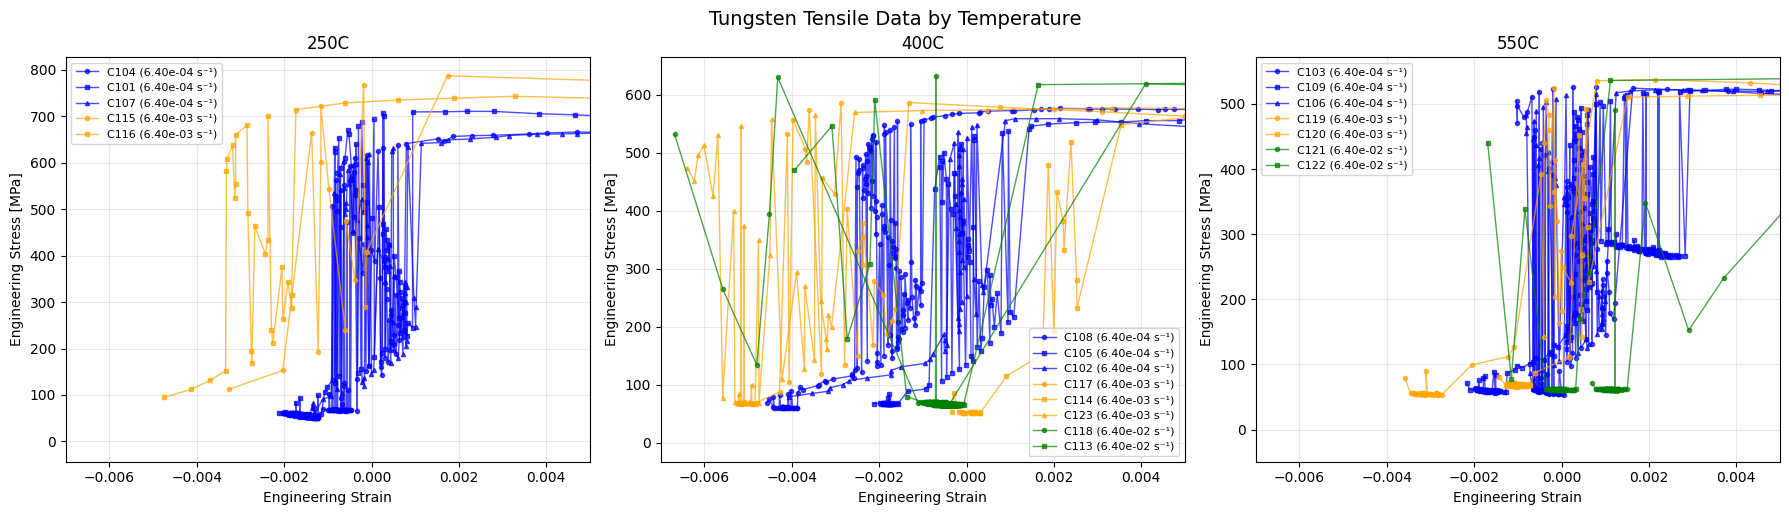

In [8]:
path = '/home/colinmoose/neml2/cmg_projects/tensile_data/W_tensile_data'

# Process each CSV file individually and track strain rate
sample_data = []

for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        
        # Extract sample name (e.g., 'C101' from 'W_C101_250C.csv')
        sample_name = filename.split('_')[1]  # Gets 'C101'
        
        # Determine temperature and strain rate
        if '250C' in filename:
            temp = 250
            temp_label = '250C'
            if sample_name in ['C101', 'C104', 'C107']:
                strain_rate = 6.4e-4
            elif sample_name in ['C115', 'C116']:
                strain_rate = 6.4e-3
            else:
                strain_rate = None
        elif '400C' in filename:
            temp = 400
            temp_label = '400C'
            if sample_name in ['C102', 'C105', 'C108']:
                strain_rate = 6.4e-4
            elif sample_name in ['C114', 'C117', 'C123']:
                strain_rate = 6.4e-3
            elif sample_name in ['C113', 'C118']:
                strain_rate = 6.4e-2
            else:
                strain_rate = None
        elif '550C' in filename:
            temp = 550
            temp_label = '550C'
            if sample_name in ['C103', 'C106', 'C109']:
                strain_rate = 6.4e-4
            elif sample_name in ['C119', 'C120']:
                strain_rate = 6.4e-3
            elif sample_name in ['C121', 'C122']:
                strain_rate = 6.4e-2
            else:
                strain_rate = None
        else:
            temp_label = 'unknown'
            temp = None
            strain_rate = None
        
        # Convert to torch tensors
        strain = torch.tensor(df['x'].values, device=device)
        stress = torch.tensor(df['y'].values, device=device)
        
        # Sort by strain
        sorted_idx = torch.argsort(strain)
        strain = strain[sorted_idx]
        stress = stress[sorted_idx]
        
        # Store the processed data
        sample_data.append({
            'sample': sample_name,
            'filename': filename,
            'temp': temp,
            'temp_label': temp_label,
            'strain_rate': strain_rate,
            'strain': strain,
            'stress': stress
        })

# Print sample info
print('--- Sample Information ---')
for data in sorted(sample_data, key=lambda x: (x['temp'] or 0, x['strain_rate'] or 0)):
    sr_str = f"{data['strain_rate']:.2e}" if data['strain_rate'] else "Unknown"
    n_points = len(data['strain'])
    print(f"{data['sample']}: {data['temp']}C, strain rate = {sr_str}, n_points = {n_points}")

# Create separate plots for each temperature
temps = ['250C', '400C', '550C']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, temp_label in enumerate(temps):
    ax = axes[idx]
    
    # Filter data for this temperature
    temp_samples = [s for s in sample_data if s['temp_label'] == temp_label]
    
    # Group by strain rate for coloring
    strain_rate_groups = {}
    for sample in temp_samples:
        sr = sample['strain_rate']
        if sr not in strain_rate_groups:
            strain_rate_groups[sr] = []
        strain_rate_groups[sr].append(sample)
    
    # Plot each strain rate group with different colors
    colors = {6.4e-4: 'blue', 6.4e-3: 'orange', 6.4e-2: 'green'}
    markers = ['o', 's', '^', 'v', '<', '>', 'd', 'p']
    
    for sr_idx, (strain_rate, samples) in enumerate(sorted(strain_rate_groups.items(), key=lambda x: x[0] if x[0] else 0)):
        for sample_idx, sample in enumerate(samples):
            strain_np = sample['strain'].cpu().numpy()
            stress_np = sample['stress'].cpu().numpy()
            
            sr_label = f"{strain_rate:.2e} s⁻¹" if strain_rate else "Unknown"
            label = f"{sample['sample']} ({sr_label})"
            color = colors.get(strain_rate, 'gray')
            marker = markers[sample_idx % len(markers)]
            
            ax.plot(strain_np, stress_np, 
                   marker=marker, markersize=3, linestyle='-', 
                   color=color, alpha=0.7, linewidth=1,
                   label=label)
    
    ax.set_xlabel('Engineering Strain')
    ax.set_ylabel('Engineering Stress [MPa]')
    ax.set_xlim([-0.007, 0.005])
    ax.set_title(f'{temp_label}')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Tungsten Tensile Data by Temperature', y=1.02, fontsize=14)
plt.show()

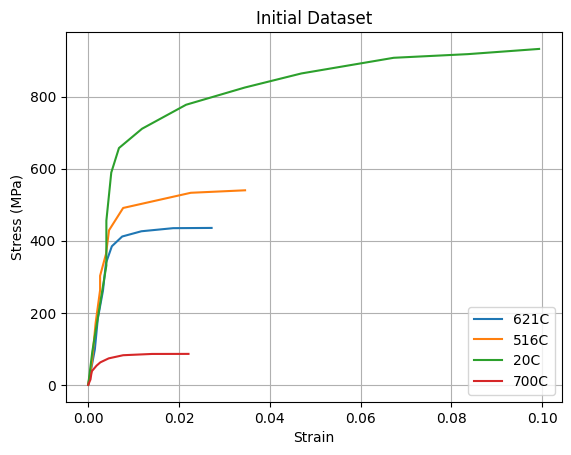

In [9]:
# Load experimental data
path = '/home/colinmoose/neml2/cmg_projects/tensile_data/var_temp_and_erate'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if 'RT' in filename:
            temp_label = '20'
        elif '516' in filename:
            temp_label = '516'
        elif '621' in filename:
            temp_label = '621'
        elif '700' in filename:
            temp_label = '700'
        else:
            temp_label = 'unknown'
        
        new_df = df.rename(columns={'x':f'{temp_label}_strain', 'y':f'{temp_label}_stress'})
        data_frames[temp_label] = new_df

strain_data = {}
stress_data = {}

for temp_label, df in data_frames.items():
    strain_col = f'{temp_label}_strain'
    stress_col = f'{temp_label}_stress'
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    max_stress_idx = torch.argmax(stress).item()
    strain = strain[:max_stress_idx + 1]
    stress = stress[:max_stress_idx + 1]
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[temp_label] = strain
    stress_data[temp_label] = stress

# Plot initial dataset
plt.figure()
for temp_label in strain_data:
    plt.plot(strain_data[temp_label].cpu().numpy(), stress_data[temp_label].cpu().numpy(), label=f"{temp_label}C")
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Initial Dataset')
plt.grid()
plt.legend()
plt.show()

In [10]:
nrate = 4
ntemperature = 4
nbatch = 4
ntime = 100
rates = torch.tensor([1.0e-4, 4.0e-5, 4.0e-3, 1.38e-6], device=device)
temperatures = torch.tensor([20, 516, 621, 700], device=device)
print(f"--- Initial Experimental Conditions ---\nstrain rates:\n{rates}\ntemperatures:\n{temperatures}")

--- Initial Experimental Conditions ---
strain rates:
tensor([1.0000e-04, 4.0000e-05, 4.0000e-03, 1.3800e-06], device='cuda:0')
temperatures:
tensor([ 20, 516, 621, 700], device='cuda:0')


In [11]:
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    # Get the actual strain range from experimental data
    min_strain = strain_data[t_label].min().item()
    max_strain = strain_data[t_label].max().item()
    
    print(f"Temperature {t_label}C: strain range [{min_strain:.4f}, {max_strain:.4f}]")
    
    # Create loading (strain) values within this range
    strain_values = torch.linspace(min_strain, max_strain, ntime, device=device)
    time_values = torch.linspace(min_strain, max_strain/rates[i].item(), ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    
    # Set temperature
    temperature[:, i, 0] = T

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")

Temperature 20C: strain range [0.0000, 0.0993]
Temperature 516C: strain range [0.0000, 0.0346]
Temperature 621C: strain range [0.0000, 0.0272]
Temperature 700C: strain range [0.0000, 0.0221]

--- Full Input Tensors ---
time: torch.Size([100, 4, 1])
temperature: torch.Size([100, 4, 1])
loading: torch.Size([100, 4, 6])


Initial data size for 621:
torch.Size([10])
Initial data size for 516:
torch.Size([10])
Initial data size for 20:
torch.Size([14])
Initial data size for 700:
torch.Size([10])
Interpolated data for 20C:
  Strain range: [0.0000, 0.0993]
  Stress range: [0.0000, 931.9826]
Interpolated data for 516C:
  Strain range: [0.0000, 0.0346]
  Stress range: [0.0000, 539.8281]
Interpolated data for 621C:
  Strain range: [0.0000, 0.0272]
  Stress range: [0.0000, 435.4626]
Interpolated data for 700C:
  Strain range: [0.0000, 0.0221]
  Stress range: [0.0000, 86.0643]


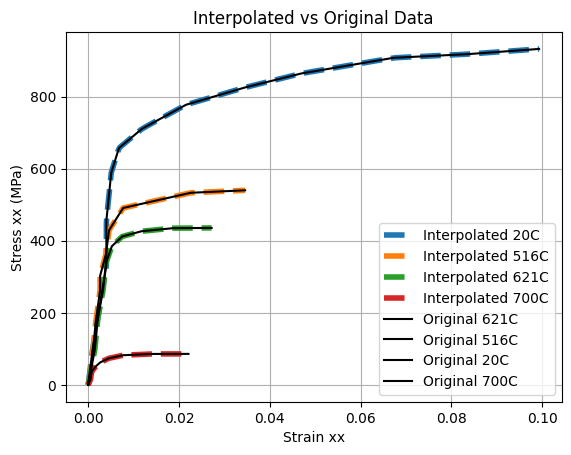

In [12]:
# Initial data shape
for temp_label in stress_data:
    print(f"Initial data size for {temp_label}:\n{stress_data[temp_label].shape}")

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    
    f_strain = torch.nn.functional.interpolate(strain_data[t_label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    f_stress = torch.nn.functional.interpolate(stress_data[t_label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    
    exp_strain_data[:, i, 0] = f_strain
    exp_stress_data[:, i, 0] = f_stress
    
    print(f"Interpolated data for {t_label}C:")
    print(f"  Strain range: [{exp_strain_data[:, i, 0].min():.4f}, {exp_strain_data[:, i, 0].max():.4f}]")
    print(f"  Stress range: [{exp_stress_data[:, i, 0].min():.4f}, {exp_stress_data[:, i, 0].max():.4f}]")

# Plot interpolated data
plt.figure()
for i, T in enumerate(temperatures):
    t_label = str(int(T.item()))
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--', color=f'C{i}', lw=4, label=f"Interpolated {t_label}C")
for temp_label in strain_data:
    plt.plot(strain_data[temp_label].cpu().numpy(), stress_data[temp_label].cpu().numpy(), color='k', label=f"Original {temp_label}C")
plt.xlabel("Strain xx")
plt.ylabel("Stress xx (MPa)")
plt.title("Interpolated vs Original Data")
plt.grid()
plt.legend()
plt.show()


Temp 20C: E = 101807.47 MPa, E_exp = 101807.47 MPa
  Yield stress: 676.74 MPa at strain: 0.0086
Temp 516C: E = 76634.31 MPa, E_exp = 76634.31 MPa
  Yield stress: 492.91 MPa at strain: 0.0084
Temp 621C: E = 67211.36 MPa, E_exp = 67211.36 MPa
  Yield stress: 413.98 MPa at strain: 0.0082
Temp 700C: E = 29890.25 MPa, E_exp = 29890.25 MPa
  Yield stress: 73.25 MPa at strain: 0.0045


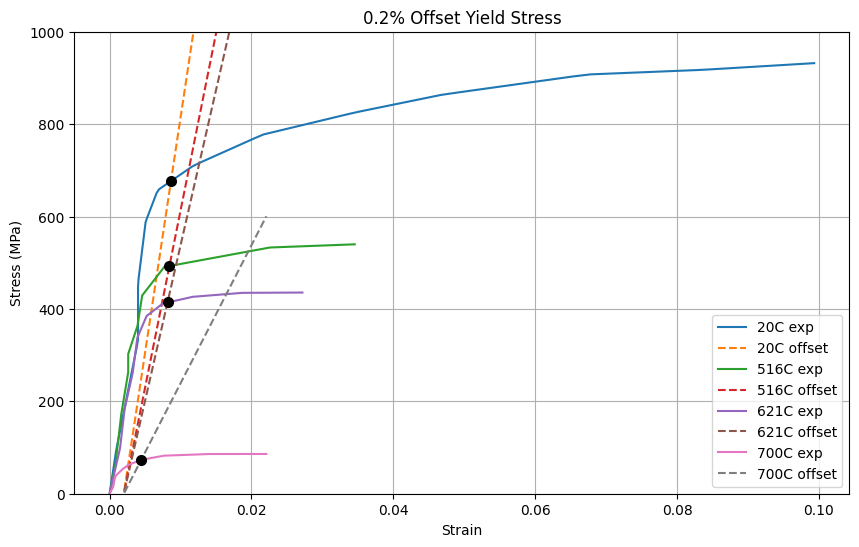


Experimental E values: [101807.46502653  76634.31232093  67211.3619677   29890.25012762]
Experimental sy values: [676.73816576 492.90807825 413.98290585  73.25199063]
Experimental G values: [39156.7173179  29474.73550805 25850.52383373 11496.25004908]
Updated E:  tensor([101807.4650,  76634.3123,  67211.3620,  29890.2501], device='cuda:0')
Updated sy: tensor([676.7382, 492.9081, 413.9829,  73.2520], device='cuda:0',
       requires_grad=True)


In [15]:
# Find the yield stress for each temperature
E = nmodel.E_Y.tensor().clone().torch() # current Young's Modulus for model
sy = nmodel.sy_Y.tensor().clone().torch()
nu = nmodel.elasticity_nu.tensor().clone().torch()
offset = 0.002

sy_exps = []
E_exps = []

plt.figure(figsize=(10, 6))

for i, T in enumerate(temperatures):
    temp_label = str(int(T.item()))

    # Calculate actual experimental Young's Modulus
    strain_initial = exp_strain_data[:5, i, 0].cpu().numpy()
    stress_initial = exp_stress_data[:5, i, 0].cpu().numpy()
    E_exp = np.polyfit(strain_initial, stress_initial, 1)[0]
    E_exps.append(E_exp)
    print(f"Temp {temp_label}C: E = {E[i]:.2f} MPa, E_exp = {E_exp:.2f} MPa")

    # Grab experimental data (keep on GPU)
    stress_exp = exp_stress_data[:, i, 0]
    strain_range = exp_strain_data[:, i, 0]

    # Build 0.2% offset line: E * (strain - 0.002), zero below offset
    valid_idx = strain_range >= offset
    stress_offset = torch.zeros_like(strain_range)
    stress_offset[valid_idx] = E_exp * (strain_range[valid_idx] - offset)

    # Find yield point: first sign change of (stress_exp - stress_offset) in valid region
    diff = stress_exp - stress_offset
    diff_valid = diff[valid_idx]
    strain_valid = strain_range[valid_idx]
    stress_valid = stress_exp[valid_idx]

    sign_changes = torch.where(torch.diff(torch.sign(diff_valid)) != 0)[0]

    if len(sign_changes) > 0:
        idx = sign_changes[0].item()
        # Linear interpolation between the two bracketing points
        d0, d1 = diff_valid[idx].item(), diff_valid[idx + 1].item()
        s0, s1 = strain_valid[idx].item(), strain_valid[idx + 1].item()
        se0, se1 = stress_valid[idx].item(), stress_valid[idx + 1].item()

        t = d0 / (d0 - d1)  # interpolation parameter in [0, 1]
        yield_strain = s0 + t * (s1 - s0)
        yield_stress = se0 + t * (se1 - se0)

        sy_exps.append(yield_stress)
        print(f"  Yield stress: {yield_stress:.2f} MPa at strain: {yield_strain:.4f}")
        plt.plot(yield_strain, yield_stress, 'ko', markersize=7, zorder=5)
    else:
        print(f"  WARNING: No intersection found for {temp_label}C — check offset or data range")
        sy_exps.append(np.nan)

    # Plot experimental curve and offset line
    plt.plot(strain_range.cpu().numpy(), stress_exp.cpu().numpy(), '-', label=f"{temp_label}C exp")
    plt.plot(strain_range[valid_idx].cpu().numpy(), stress_offset[valid_idx].cpu().numpy(),
             '--', label=f"{temp_label}C offset")

plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('0.2% Offset Yield Stress')
plt.legend()
plt.grid()
plt.ylim((0.0, 1000.0))
plt.show()

# Replace model parameters with experimental values to improve training
E_exps = np.array(E_exps)
sy_exps = np.array(sy_exps)

# Compute G from experimental E: G = E / (2*(1+nu))
G_exps = E_exps / (2.0 * (1.0 + nu.cpu().numpy()))

print(f"\nExperimental E values: {E_exps}")
print(f"Experimental sy values: {sy_exps}")
print(f"Experimental G values: {G_exps}")

E_tensor  = torch.tensor(E_exps, device=device, dtype=torch.double)
sy_tensor = torch.tensor(sy_exps[~np.isnan(sy_exps)], device=device, dtype=torch.double)
G_tensor  = torch.tensor(G_exps, device=device, dtype=torch.double)

with torch.no_grad():
    E_param  = nmodel.E_Y.tensor().torch()
    sy_param = nmodel.sy_Y.tensor().torch()
    E_param.copy_(E_tensor)
    sy_param.copy_(sy_tensor)
    print(f"Updated E:  {nmodel.E_Y.tensor().torch()}")
    print(f"Updated sy: {nmodel.sy_Y.tensor().torch()}")


In [14]:
with torch.no_grad():
    stress = model(time, temperature, loading)

RuntimeError: shape '[50, 4, 6]' is invalid for input of size 4800